# E-commerce A/B Testing Analysis

Statistical evaluation of an A/B test using hypothesis testing and logistic regression.

## Business Problem
The company launched a new landing page and wanted to determine whether it increased user conversion rate compared to the existing page.

Because even small conversion improvements can impact revenue at scale, the goal of this analysis was to determine whether the observed difference was statistically significant and practically meaningful.

## Project Goal
This project aims to:
- Compare conversion rates between the old and new pages
- Determine whether the difference is statistically significant
- Validate whether the sample size was sufficient
- Measure the uncertainty of the result using confidence intervals
- Evaluate whether country differences affected the outcome

## Dataset Overview

datas source: https://www.kaggle.com/code/ahmedmohameddawoud/e-commerce-a-b-testing-project-walk-through/input

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm
import matplotlib.pyplot as plt
from statsmodels.formula.api import logit
import statsmodels.formula.api as smf

In [6]:
df_ab_test= pd.read_csv('ab_test.csv')
df_countries= pd.read_csv('countries_ab.csv')

In [7]:
df_ab_test.head()

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [8]:
print(df_ab_test.head(3))
print()
print(df_ab_test.shape)
print()
print(df_ab_test.info())

       id     time  con_treat      page  converted
0  851104  11:48.6    control  old_page          0
1  804228  01:45.2    control  old_page          0
2  661590  55:06.2  treatment  new_page          0

(294478, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         294478 non-null  int64 
 1   time       294478 non-null  object
 2   con_treat  294478 non-null  object
 3   page       294478 non-null  object
 4   converted  294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None


In [9]:
print(df_countries.head(3))
print()
print(df_countries.shape)
print()
print(df_countries.info())

       id country
0  834778      UK
1  928468      US
2  822059      UK

(290584, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290584 entries, 0 to 290583
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   id       290584 non-null  int64 
 1   country  290584 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.4+ MB
None


## Data Cleaning

In [11]:
pd.crosstab(df_ab_test['con_treat'], df_ab_test['page'])

page,new_page,old_page
con_treat,,
control,1928,145274
treatment,145311,1965


Some records contained inconsistent combinations between group assignment and landing page version:

- treatment users seeing the old page
- control users seeing the new page

These observations were removed to preserve the integrity of the A/B test structure.

Such mismatches may occur due to:
- logging inconsistencies
- experiment assignment errors
- implementation issues during the test

The mismatch records are removed before analysis. As keeping these records could bias the experiment results because users would not actually be exposed to their assigned experience.

In [13]:
df_clean= df_ab_test[
    ((df_ab_test['con_treat']=='treatment') & (df_ab_test['page']=="new_page"))|
    ((df_ab_test['con_treat']=='control') & (df_ab_test['page']=='old_page'))]

pd.crosstab(df_clean['con_treat'], df_clean['page'])

page,new_page,old_page
con_treat,,
control,0,145274
treatment,145311,0


In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290585 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         290585 non-null  int64 
 1   time       290585 non-null  object
 2   con_treat  290585 non-null  object
 3   page       290585 non-null  object
 4   converted  290585 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 13.3+ MB


In [15]:
df_clean.groupby('con_treat')['converted'].mean()

con_treat
control      0.120386
treatment    0.118807
Name: converted, dtype: float64



The new page appears to have a slightly lower conversion rate.
Because the observed difference is based on a sample, it may be due to random variation rather than a true effect, so we need statistical testing to determine if the difference is significant

# Sample Size Validation

**Note on MDE Selection:** For this analysis, the Minimum Detectable Effect (MDE) is set to **0.5pp (0.005)**. In high-traffic e-commerce environments, even a 0.5 percentage point increase in conversion can represent significant revenue growth, making it a more realistic target for optimization than larger lifts. Note that this threshold is an analytical assumption for this project.


In [18]:
MDE = 0.005

p_control = 0.1204
p2 = p_control + MDE
p_pool = (p_control + p2) / 2
effect = abs(p_control - p2) / np.sqrt(p_pool * (1 - p_pool))

z_alpha = norm.ppf(0.975)
z_beta  = norm.ppf(0.80)

required_n = int(((z_alpha + z_beta) / effect) ** 2)
print(f'MDE set to: {MDE*100}pp')
print(f'Required n per group: {required_n:,}')
print(f'We have: ~145,000 per group')
print(f'Conclusion: {"Sufficient" if 145000 >= required_n else "Insufficient"} sample size')

MDE set to: 0.5pp
Required n per group: 33,842
We have: ~145,000 per group
Conclusion: Sufficient sample size


# Hypothesis Testing

Hypothesis:

- H0: There is no difference in conversion rate between the new page and the old page.
- H1: The conversion rate of the new page is different from the conversion rate of the old page.

Using a two-sided hypothesis test to determine if there is a statistically significant difference in conversion rate.

In [21]:
df_grouped= df_clean.groupby('page').agg({
    'page': ['count'],
    'converted': ['sum']})

df_grouped

,page,converted
,count,sum
page,,
new_page,145311,17264
old_page,145274,17489


In [22]:
from statsmodels.stats.proportion import proportions_ztest

control   = df_clean[df_clean['con_treat'] == 'control']
treatment = df_clean[df_clean['con_treat'] == 'treatment']

counts = [treatment['converted'].sum(), control['converted'].sum()]
nobs   = [len(treatment), len(control)]

z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')
print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value:     {p_value:.4f}')

Z-statistic: -1.3116
P-value:     0.1897


**Conclusion:**
- The two-proportion z-test returned a p-value of 0.1897, which is greater than the significance level of 0.05.
- Therefore, we fail to reject the null hypothesis H0.
- Based on this test, there is not enough statistical evidence to conclude that the new page produces a different conversion rate from the old page.

## Confidence Interval Analysis

In [25]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    count1=treatment['converted'].sum(), nobs1=len(treatment),
    count2=control['converted'].sum(),   nobs2=len(control),
    method='wald'
)

print(f'Treatment rate: {treatment["converted"].mean()*100:.4f}%')
print(f'Control rate:   {control["converted"].mean()*100:.4f}%')
print(f'Observed difference: {(treatment["converted"].mean() - control["converted"].mean())*100:.4f}pp')
print(f'95% CI for (treatment - control): [{ci_low*100:.4f}pp, {ci_high*100:.4f}pp]')

Treatment rate: 11.8807%
Control rate:   12.0386%
Observed difference: -0.1579pp
95% CI for (treatment - control): [-0.3939pp, 0.0781pp]


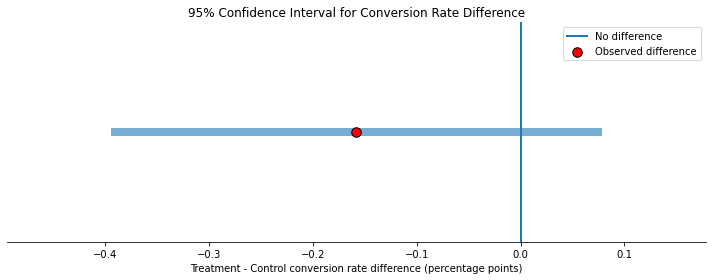

In [63]:
fig, ax = plt.subplots(figsize=(10, 4))

ci_low_pp = ci_low * 100
ci_high_pp = ci_high * 100
diff_pp = (counts[0] / nobs[0] - counts[1] / nobs[1]) * 100

ax.hlines(y=0, xmin=ci_low_pp, xmax=ci_high_pp, linewidth=8, alpha=0.6)
ax.scatter(diff_pp, 0, s=90, color= 'red', edgecolor='black', zorder=3, label='Observed difference')
ax.axvline(0, linewidth=2, linestyle='-', label='No difference')

ax.set_title('95% Confidence Interval for Conversion Rate Difference')
ax.set_xlabel('Treatment - Control conversion rate difference (percentage points)')
ax.set_yticks([])

padding = 0.1
ax.set_xlim(ci_low_pp - padding, ci_high_pp + padding)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.legend(loc='best')
plt.tight_layout()
plt.show()

**Conclusion:**

- The observed difference between treatment and control was very small, and the 95% confidence interval crossed zero, indicating that the true effect could reasonably be either slightly negative or slightly positive.
  
- This supports the earlier hypothesis test result that there is no statistically significant difference between the two pages.

# Controlling for Country Effects

To further validate the experiment result, Logistic Regression was used to check whether users from different countries responded differently to the new landing page.

In [29]:
df_merged= pd.merge(df_clean, df_countries, on='id', how='inner')

country_summary = df_merged.groupby(['country', 'con_treat'])['converted'].agg(['count', 'mean']).round(4)
country_summary.columns = ['users', 'conversion_rate']
country_summary

users  conversion_rate
country con_treat                         
CA      control      7198           0.1188
        treatment    7301           0.1119
UK      control     36360           0.1200
        treatment   36106           0.1212
US      control    101716           0.1206
        treatment  101904           0.1185

In [30]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290585 entries, 0 to 290584
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         290585 non-null  int64 
 1   time       290585 non-null  object
 2   con_treat  290585 non-null  object
 3   page       290585 non-null  object
 4   converted  290585 non-null  int64 
 5   country    290585 non-null  object
dtypes: int64(2), object(4)
memory usage: 25.5+ MB


In [31]:
df_merged['id'].duplicated().sum()

1

In [32]:
df_merged = df_merged.drop_duplicates(subset=['id'], keep='first')

df_merged.shape

(290584, 6)

In [33]:
pd.crosstab(df_merged['country'], df_merged['con_treat'])

con_treat,control,treatment
country,,
CA,7198,7301
UK,36360,36106
US,101716,101903


Treatment and control balance across countries

### Logistic Regression Analysis

In [36]:
df_model = df_merged.copy()

In [37]:
model_multi = smf.logit(
    formula='converted ~ C(con_treat) * C(country)',
    data=df_model
).fit()

model_multi.summary()

Optimization terminated successfully.
         Current function value: 0.366109
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290578
Method:                           MLE   Df Model:                            5
Date:                Tue, 19 May 2026   Pseudo R-squ.:               3.482e-05
Time:                        18:37:55   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1920
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -2.0040      0.036    -55.008      0.000      -2.075      -1.933
C(con_treat)[T.treatment]                     -0.0674      0.052     -1.297      0.195      -0.169       0.034
C(country)[T.UK]                               0.0118      0.040      0.296      0.767      -0.066       0.090
C(country)[T.US]                               0.0175      0.038      0.465      0.642      -0.056       0.091
C(con_treat)[T.treatment]:C(country)[T.UK]     0.0783      0.057      1.378      0.168      -0.033       0.190
C(con_treat)[T.treatment]:C(country)[T.US]     0.0469      0.054      0.872      0.383      -0.059       0.152
==============================================================================================================
"""

The regression results showed that:

- The main treatment effect remained statistically insignificant
- The country interaction terms were also not statistically significant

This suggests that the new page did not meaningfully improve conversion rates in any specific country within this dataset.

Therefore, there is no strong evidence that country-specific behavior changed the overall experiment conclusion.

## Final Business Conclusion

### Final Conclusion
The analysis found **no statistically significant improvement in conversion rate** from the new landing page.

Key findings:
- The treatment group slightly underperformed the control group
- The observed difference was very small
- The experiment had sufficient sample size and statistical power
- Confidence intervals suggest the true effect is likely close to zero
- Logistic regression showed no meaningful country-specific treatment effects

### Business Recommendation
Based on the current evidence, the company **should not replace the existing landing page with the new version**.
Instead, the team may consider:
- Testing larger design changes
- Running new experiments with different user experiences
- Investigating specific user segments or behavioral patterns